In [1]:
#Program Name: IST 652 Final Project 
#Program Author: K.Roller
#Program Created: Sept. 4th, 2024
#Program Purpose: To meet the requirements set forth in the final project criteria 
#
#
#Loading in numpy and pandas before getting started 
import pandas as pd
import numpy as np

In [3]:
#Setting the file path for each of the data sets we hope to use in analysis. 
#The primary dataset consist of the number of drivers in all 50 states with supporting datasets to be joined.
#Adding additional data will most likely require trimming of the original data, the supporting data, or both
file_path1="C:/Users/super/OneDrive/Desktop/Licensed_drivers_By_State.csv"
file_path2="C:/Users/super/Downloads/annual_amtrak_ridership.xlsx"
file_path3="C:/Users/super/Downloads/Fuel_Tax_Rates.xlsx"
file_path4="C:/Users/super/Downloads/Road_condition.xlsx"
file_path5="C:/Users/super/Downloads/emp-unemployment.xls"


In [4]:
#Read in the data files 
licensed_drivers=pd.read_csv(file_path1)

In [11]:
amtrak_riders=pd.read_excel(file_path2)
fuel_tax=pd.read_excel(file_path3)
road_cond=pd.read_excel(file_path4, header=None)
emp_unemp=pd.read_excel(file_path5, sheet_name=1)

In [13]:
#Now we need to check the dimensionality of each of the datasets. Ideally we trim the additional
# data to meet the primary data as best as possible. 
print(licensed_drivers.head())
print(amtrak_riders.head())
print(fuel_tax.head())
print(road_cond.head())
print(emp_unemp.head(10))


   Year Gender    Cohort       State  Drivers
0  2017   Male  Under 16     Alabama      0.0
1  2017   Male  Under 16      Alaska      0.0
2  2017   Male  Under 16     Arizona      0.0
3  2017   Male  Under 16    Arkansas      0.0
4  2017   Male  Under 16  California      0.0
        State     2022     2021     2020      2019      2018      2017  \
0     Alabama    29086    20603    24714     51172     54646     57338   
1     Arizona    70851    47075    57096     99636    105254    111242   
2    Arkansas    24482    15383    18795     30413     33736     35060   
3  California  6414831  3526804  5962944  11455840  12306438  12347680   
4    Colorado   197053   114529   174346    270232    267070    279589   

       2016        2015      2014      2013      2012      2011      2010  \
0     58395     60992.0     63170     66192     67233     66922     63577   
1    108629    110619.0    105780    107072    104381    102994     99477   
2     32399     34988.0     36885     41183     

In [15]:
#Ok, pretty messy. We will start by looking at the licensed_drivers data and making sure it is clean first
print(licensed_drivers.isna().sum())

Year       0
Gender     0
Cohort     0
State      0
Drivers    1
dtype: int64


In [18]:
print(licensed_drivers.shape)

(57834, 5)


In [19]:
#Ok,so now we need to check the other datasets year range and make sure to trim to fit this dataset
# before attempting to joing them. The year range we need to match is 1994-2018. So lets work through
# the datasets and match the years for each additional set. 
#First we will check NaN counts in the amtrak_riders data: 
print(amtrak_riders.isna().sum())

State    0
2022     0
2021     0
2020     0
2019     0
2018     0
2017     0
2016     0
2015     0
2014     0
2013     0
2012     0
2011     0
2010     0
2009     0
2008     2
2007     1
2006     0
2005     0
dtype: int64


In [20]:
#This is rather unfortunate, as it seems we will have to trim a substantial number of years from 
# the orginal dataset to match this one. Additionally will need to trim this data as well. 
# Need to see what to call the year with
print(amtrak_riders.columns)

Index(['State', '2022', '2021', '2020', '2019', '2018', '2017', '2016', '2015',
       '2014', '2013', '2012', '2011', '2010', '2009', '2008', '2007', '2006',
       '2005'],
      dtype='object')


In [28]:
print(amtrak_riders.head())
#Hmmm

        State     2022     2021     2020      2019      2018      2017  \
0     Alabama    29086    20603    24714     51172     54646     57338   
1     Arizona    70851    47075    57096     99636    105254    111242   
2    Arkansas    24482    15383    18795     30413     33736     35060   
3  California  6414831  3526804  5962944  11455840  12306438  12347680   
4    Colorado   197053   114529   174346    270232    267070    279589   

       2016        2015      2014      2013      2012      2011      2010  \
0     58395     60992.0     63170     66192     67233     66922     63577   
1    108629    110619.0    105780    107072    104381    102994     99477   
2     32399     34988.0     36885     41183     41358     39617     37969   
3  12148179  11890454.0  11514763  12218615  11990378  12003478  11226636   
4    250711    226364.0    202718    198216    205942    206428    219652   

       2009        2008        2007     2006     2005  
0     47957     47944.0     40068.0 

In [29]:
print(amtrak_riders.loc[amtrak_riders['State']=='Texas'])
#Well thats not exactly how imagined this would be read in but this is fine. 
# Instead of being able to call the the year by year it will need to be called by column name to trim
# This is more tedious than what was orginally planned but perfectly doable. 

    State    2022    2021    2020    2019    2018    2017    2016      2015  \
40  Texas  306300  196300  218203  363873  381615  393484  361496  380564.0   

      2014    2013    2012    2011    2010    2009      2008      2007  \
40  416407  444954  465300  425909  382754  329704  323210.0  262081.0   

      2006    2005  
40  133633  140140  


In [31]:
# Trimming the amtrak_riders data to match the overlapping years in the original data
trimmed_amtrak=amtrak_riders[['State', '2018', '2017', '2016', '2015', '2014', '2013', '2012', '2011', '2010', '2009', '2008', '2007', '2006','2005']]

In [32]:
#Checking the new data
print(trimmed_amtrak.head())

        State      2018      2017      2016        2015      2014      2013  \
0     Alabama     54646     57338     58395     60992.0     63170     66192   
1     Arizona    105254    111242    108629    110619.0    105780    107072   
2    Arkansas     33736     35060     32399     34988.0     36885     41183   
3  California  12306438  12347680  12148179  11890454.0  11514763  12218615   
4    Colorado    267070    279589    250711    226364.0    202718    198216   

       2012      2011      2010      2009        2008        2007     2006  \
0     67233     66922     63577     47957     47944.0     40068.0    17554   
1    104381    102994     99477     88044     88305.0     80370.0    37328   
2     41358     39617     37969     33264     33949.0     28297.0    13353   
3  11990378  12003478  11226636  11070560  11866636.0  10654671.0  5082169   
4    205942    206428    219652    199843    224513.0    208552.0    98314   

      2005  
0    24566  
1    36096  
2    12876  
3  4

In [33]:
#It appears the trimming was succesful, but we still need to deal with the NaN values found in the data. 
#Instead of outright removing the data we will use the mean of the data for the respective state to resovle
trimmed_amtrak['2008'].fillna(trimmed_amtrak['2008'].mean(), inplace=True)
trimmed_amtrak['2007'].fillna(trimmed_amtrak['2007'].mean(), inplace=True)
#double check that this resovles our NaN issue
print(trimmed_amtrak.isna().sum())
#Additionally look at values to make sure the means used make sense in the state they are being used
# i.e. not using the mean of California in Rhode Island
print(trimmed_amtrak[['State','2008', '2007']].head())

State    0
2018     0
2017     0
2016     0
2015     0
2014     0
2013     0
2012     0
2011     0
2010     0
2009     0
2008     0
2007     0
2006     0
2005     0
dtype: int64
        State        2008        2007
0     Alabama     47944.0     40068.0
1     Arizona     88305.0     80370.0
2    Arkansas     33949.0     28297.0
3  California  11866636.0  10654671.0
4    Colorado    224513.0    208552.0


C:\Users\super\anaconda3\lib\site-packages\pandas\core\generic.py:6392: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return self._update_inplace(result)


In [34]:
#Looks like this has resolved the NaN issues and trimmed the data to match our original as best as possible
# based on overlap. Now we can move on to the additional datasets that need to be modified before being 
# able to be joined into one. 
print(fuel_tax.isna().sum())


Effective Date    19
Fuel Type         19
Note              13
State              0
Mmfr Year          0
Rate               0
dtype: int64


In [36]:
#For this dataset we will simply remove the missing value columns in their entirety. 
trimmed_fuel=fuel_tax[['State', 'Rate']]

In [37]:
#Printing out the first few observations to make sure we cut the approrpiate values
print(trimmed_fuel.head())

         State   Rate
0  Puerto Rico  16.00
1    Louisiana  20.00
2        Texas  20.00
3     Colorado  23.69
4     Delaware  23.00


In [38]:
print(trimmed_fuel.isna().sum())

State    0
Rate     0
dtype: int64


In [39]:
#Ok, this marks the second dataset that has been modified to fit. Note, for this dataset, the only 
# year measure was for the year the fuel tax was implemented. For the sake of simplicity, this fuel tax
# rate will be assumed to be a constant for all years for each state, which for many observations is the case.
#Now to check years and NaN rates in road_cond
print(road_cond.isna().sum())

0     2
1     1
2     1
3     1
4     0
     ..
70    2
71    2
72    2
73    2
74    2
Length: 75, dtype: int64


In [40]:
print(road_cond.head())

              0              1                   2                   3   \
0            NaN  Total (miles)  Acceptable (miles)  Percent Acceptable   
1            NaN        Overall             Overall             Overall   
2          State            NaN                 NaN                 NaN   
3  United States    786012.8346         642160.7634           81.698509   
4        Alabama     11308.9328          11111.0873           98.250538   

                          4          5        6        7         8         9   \
0              Urban (miles)        NaN      NaN      NaN       NaN       NaN   
1  Other principal arterials        NaN      NaN      NaN       NaN       NaN   
2               Less than 60      60-94   95-119  120-144   145-170   171-194   
3                   7516.559  15929.909  9799.15  7723.31  6089.575  4227.971   
4                    458.143    453.026  118.861   59.855    33.584    18.204   

   ...           65             66            67        68    

In [41]:
print(road_cond.columns)

Int64Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
            17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
            34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
            51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
            68, 69, 70, 71, 72, 73, 74],
           dtype='int64')


In [116]:
#Ok, this one is a mess, this may be the result of improper loading technique. 
#However, isntead of addressing the issue on data load, we will just edit the data set as required. 
# Since this is only one years worth of data we will once again treat this as a constant.
# Likewise we can retain just the first 4 columns of this dataset
trimmed_road=road_cond[[0,1,2,3]]


In [44]:
print(trimmed_road.head())

               0              1                   2                   3
0            NaN  Total (miles)  Acceptable (miles)  Percent Acceptable
1            NaN        Overall             Overall             Overall
2          State            NaN                 NaN                 NaN
3  United States    786012.8346         642160.7634           81.698509
4        Alabama     11308.9328          11111.0873           98.250538


In [117]:
#OK, now we need to rename the columns of the data so they make sense when we combine the data
trimmed_road_copy=trimmed_road.copy()
trimmed_road_copy.rename(columns={0:'State', 1:'Total Miles', 2:'Acceptable Miles', 3:'Percent Acceptable Overall'}, inplace=True)

In [119]:
#Made a copy to resolve error stemming from trying to rename columns as dataset was. 
#Check to make sure changes took affect 
print(trimmed_road_copy.head())

           State    Total Miles    Acceptable Miles Percent Acceptable Overall
0            NaN  Total (miles)  Acceptable (miles)         Percent Acceptable
1            NaN        Overall             Overall                    Overall
2          State            NaN                 NaN                        NaN
3  United States    786012.8346         642160.7634                  81.698509
4        Alabama     11308.9328          11111.0873                  98.250538


In [120]:
#Lastly we need to remove the first three rows of data since this is a leftover from a messy import. 
trimmed_road_copy = trimmed_road_copy.loc[~trimmed_road_copy.index.isin(range(0, 4))]

print(trimmed_road_copy.head())

        State  Total Miles Acceptable Miles Percent Acceptable Overall
4     Alabama   11308.9328       11111.0873                  98.250538
5      Alaska   3617.85341       2814.08006                  77.783142
6     Arizona  16473.96398      12329.82558                  74.844315
7    Arkansas   6783.21465       6287.40097                  92.690579
8  California  19735.98632      15005.88643                  76.033121


In [121]:
print(trimmed_road_copy.isna().sum())

State                         0
Total Miles                   0
Acceptable Miles              0
Percent Acceptable Overall    0
dtype: int64


In [52]:
#Ok, we have finally got this data cleaned up and in a useable state. 
#And of course the last dataset is also an incoherent mess
print(emp_unemp.head())

  Average Annual Unemployment Rates by State (see previous tab for Iowa's counties)  \
0                    U.S. Bureau of Labor Statistics                                  
1  Local Area Unemployment Statistics and Current...                                  
2                                 April 2019 release                                  
3                                                NaN                                  
4                                               Fips                                  

  Unnamed: 1  Unnamed: 2  Unnamed: 3  Unnamed: 4  Unnamed: 5  Unnamed: 6  \
0        NaN         NaN         NaN         NaN         NaN         NaN   
1        NaN         NaN         NaN         NaN         NaN         NaN   
2        NaN         NaN         NaN         NaN         NaN         NaN   
3        NaN         NaN         NaN         NaN         NaN         NaN   
4       Area      1980.0      1981.0      1982.0      1983.0      1984.0   

   Unnamed: 7  Unnam

In [96]:
#We don't need the data that consist of years outside of the range of the other dataset.
# As such we will trim the data accordingly 
#Going to reimport with header=none to make this stage easier 
emp_unemp=pd.read_excel(file_path5, sheet_name=1, header=None)

In [97]:
print(emp_unemp.head(10))

                                                  0              1       2   \
0  Average Annual Unemployment Rates by State (se...            NaN     NaN   
1                    U.S. Bureau of Labor Statistics            NaN     NaN   
2  Local Area Unemployment Statistics and Current...            NaN     NaN   
3                                 April 2019 release            NaN     NaN   
4                                                NaN            NaN     NaN   
5                                               Fips           Area  1980.0   
6                                              00000  United States     7.1   
7                                              01000        Alabama     8.9   
8                                              02000         Alaska     9.6   
9                                              04000        Arizona     6.6   

       3       4       5       6       7       8       9   ...      31  \
0     NaN     NaN     NaN     NaN     NaN     NaN     Na

In [107]:
#Ok, now need to make the appropriate trims to the dataset
trimmed_emp_unemp=emp_unemp[[1,27,28,29,30,31,32,33,34,35,36,37,38,39,40]]
print(trimmed_emp_unemp.head())


    1   27  28  29  30  31  32  33  34  35  36  37  38  39  40
0  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN
1  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN
2  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN
3  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN
4  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN


In [108]:
#And now we need to remove the first 5 rows to remove all the blank space that was in the excel sheet
trimmed_emp_unemp=trimmed_emp_unemp.iloc[5:, :]
print(trimmed_emp_unemp.head(10))

               1       27      28      29      30      31      32      33  \
5            Area  2005.0  2006.0  2007.0  2008.0  2009.0  2010.0  2011.0   
6   United States     5.1     4.6     4.6     5.8     9.3     9.6     8.9   
7         Alabama     4.5     4.0     4.0     5.7    11.0    10.5     9.6   
8          Alaska     6.9     6.6     6.3     6.7     7.7     7.9     7.6   
9         Arizona     4.7     4.2     3.9     6.2     9.9    10.4     9.5   
10       Arkansas     5.2     5.2     5.3     5.5     7.8     8.2     8.3   
11     California     5.4     4.9     5.4     7.3    11.2    12.2    11.7   
12       Colorado     5.0     4.3     3.7     4.8     7.3     8.7     8.4   
13    Connecticut     4.9     4.3     4.5     5.7     7.9     9.1     8.8   
14       Delaware     4.1     3.6     3.4     4.9     8.3     8.4     7.5   

        34      35      36      37      38      39      40  
5   2012.0  2013.0  2014.0  2015.0  2016.0  2017.0  2018.0  
6      8.1     7.4     6.2    

In [109]:
trimmed_emp_unemp.rename(columns={1:'Area', 27:'2005', 28:'2006', 29:'2007', 30:'2008', 31:'2009',32:'2010', 33:'2011', 34:'2012', 35:'2013', 36:'2014', 37:'2015',38:'2016', 39:'2017', 40:'2018' }, inplace=True)

In [110]:
print(trimmed_emp_unemp.head())

            Area    2005    2006    2007    2008    2009    2010    2011  \
5           Area  2005.0  2006.0  2007.0  2008.0  2009.0  2010.0  2011.0   
6  United States     5.1     4.6     4.6     5.8     9.3     9.6     8.9   
7        Alabama     4.5     4.0     4.0     5.7    11.0    10.5     9.6   
8         Alaska     6.9     6.6     6.3     6.7     7.7     7.9     7.6   
9        Arizona     4.7     4.2     3.9     6.2     9.9    10.4     9.5   

     2012    2013    2014    2015    2016    2017    2018  
5  2012.0  2013.0  2014.0  2015.0  2016.0  2017.0  2018.0  
6     8.1     7.4     6.2     5.3     4.9     4.4     3.9  
7     8.0     7.2     6.8     6.1     5.8     4.4     3.9  
8     7.1     7.0     6.9     6.5     6.9     7.0     6.6  
9     8.3     7.7     6.8     6.1     5.4     4.9     4.8  


In [111]:
#OK, so now we have the data trimmed down to the appropiate years and have cleaned up the column names
#Now we need to remove the first row and then double check for NaN values 
trimmed_emp_unemp = trimmed_emp_unemp.loc[~trimmed_emp_unemp.index.isin(range(5,7))]
print(trimmed_emp_unemp.head())

          Area  2005  2006  2007  2008  2009  2010  2011  2012  2013  2014  \
7      Alabama   4.5   4.0   4.0   5.7  11.0  10.5   9.6   8.0   7.2   6.8   
8       Alaska   6.9   6.6   6.3   6.7   7.7   7.9   7.6   7.1   7.0   6.9   
9      Arizona   4.7   4.2   3.9   6.2   9.9  10.4   9.5   8.3   7.7   6.8   
10    Arkansas   5.2   5.2   5.3   5.5   7.8   8.2   8.3   7.6   7.2   6.0   
11  California   5.4   4.9   5.4   7.3  11.2  12.2  11.7  10.4   8.9   7.5   

    2015  2016  2017  2018  
7    6.1   5.8   4.4   3.9  
8    6.5   6.9   7.0   6.6  
9    6.1   5.4   4.9   4.8  
10   5.0   4.0   3.7   3.7  
11   6.2   5.5   4.8   4.2  


In [112]:
#Ok, that should be correct
print(trimmed_emp_unemp.isna().sum())

Area    9
2005    9
2006    9
2007    9
2008    9
2009    9
2010    9
2011    9
2012    9
2013    9
2014    9
2015    9
2016    9
2017    9
2018    9
dtype: int64


In [113]:
#Doesnt seem right as the data set was complete with no missing values for any of the observations 
print(trimmed_emp_unemp)

                    Area  2005  2006  2007  2008  2009  2010  2011  2012  \
7                Alabama   4.5   4.0   4.0   5.7  11.0  10.5   9.6   8.0   
8                 Alaska   6.9   6.6   6.3   6.7   7.7   7.9   7.6   7.1   
9                Arizona   4.7   4.2   3.9   6.2   9.9  10.4   9.5   8.3   
10              Arkansas   5.2   5.2   5.3   5.5   7.8   8.2   8.3   7.6   
11            California   5.4   4.9   5.4   7.3  11.2  12.2  11.7  10.4   
12              Colorado   5.0   4.3   3.7   4.8   7.3   8.7   8.4   7.9   
13           Connecticut   4.9   4.3   4.5   5.7   7.9   9.1   8.8   8.3   
14              Delaware   4.1   3.6   3.4   4.9   8.3   8.4   7.5   7.2   
15  District of Columbia   6.4   5.8   5.5   6.5   9.3   9.4  10.2   9.0   
16               Florida   3.7   3.2   4.0   6.3  10.4  11.1  10.0   8.5   
17               Georgia   5.3   4.7   4.5   6.2   9.9  10.5  10.2   9.2   
18                Hawaii   2.9   2.6   2.8   4.3   7.2   6.9   6.8   6.0   
19          

In [86]:
#Aha, so we need to remove the last few rows as well
trimmed_emp_unemp_copy=trimmed_emp_unemp.iloc[59:67, :]
print(trimmed_emp_unemp_copy.isna().sum())

Area    0.0
2005    0.0
2006    0.0
2007    0.0
2008    0.0
2009    0.0
2010    0.0
2011    0.0
2012    0.0
2013    0.0
2014    0.0
2015    0.0
2016    0.0
2017    0.0
2018    0.0
dtype: float64


In [87]:
print(trimmed_emp_unemp_copy.head())
print(trimmed_emp_unemp.head())

Empty DataFrame
Columns: [Area, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]
Index: []
        Area  2005  2006  2007  2008  2009  2010  2011  2012  2013  2014  \
17   Georgia   5.3   4.7   4.5   6.2   9.9  10.5  10.2   9.2   8.2   7.1   
18    Hawaii   2.9   2.6   2.8   4.3   7.2   6.9   6.8   6.0   4.9   4.4   
19     Idaho   4.0   3.5   3.1   5.1   8.8   9.0   8.3   7.2   6.1   4.8   
20  Illinois   5.7   4.5   5.0   6.3  10.2  10.4   9.7   9.0   9.0   7.1   
21   Indiana   5.5   5.0   4.6   5.9  10.3  10.4   9.1   8.3   7.7   6.0   

    2015  2016  2017  2018  
17   6.0   5.4   4.7   3.9  
18   3.6   3.0   2.4   2.4  
19   4.2   3.8   3.2   2.8  
20   6.0   5.8   4.9   4.3  
21   4.8   4.4   3.6   3.4  


In [88]:
print(trimmed_emp_unemp.shape)

(50, 15)


In [93]:
trimmed_emp_unemp_copy=trimmed_emp_unemp.loc[58:66 , :]
print(trimmed_emp_unemp_copy.head())

   Area  2005  2006  2007  2008  2009  2010  2011  2012  2013  2014  2015  \
58  NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
59  NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
60  NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
61  NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
62  NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   

    2016  2017  2018  
58   NaN   NaN   NaN  
59   NaN   NaN   NaN  
60   NaN   NaN   NaN  
61   NaN   NaN   NaN  
62   NaN   NaN   NaN  


In [114]:
#Ok, having problems with indexing correctly because it seems to work differently than in R
# and annoyingly cannot just used -c() as an argument to specify rows to be removed....ok
# So what is the python way?
#The use of ~df(range(,)) will let us specify which rows we want to exclude from the data
trimmed_emp_unemp_copy = trimmed_emp_unemp.loc[~trimmed_emp_unemp.index.isin(range(58, 67))]
print(trimmed_emp_unemp_copy.head())


          Area  2005  2006  2007  2008  2009  2010  2011  2012  2013  2014  \
7      Alabama   4.5   4.0   4.0   5.7  11.0  10.5   9.6   8.0   7.2   6.8   
8       Alaska   6.9   6.6   6.3   6.7   7.7   7.9   7.6   7.1   7.0   6.9   
9      Arizona   4.7   4.2   3.9   6.2   9.9  10.4   9.5   8.3   7.7   6.8   
10    Arkansas   5.2   5.2   5.3   5.5   7.8   8.2   8.3   7.6   7.2   6.0   
11  California   5.4   4.9   5.4   7.3  11.2  12.2  11.7  10.4   8.9   7.5   

    2015  2016  2017  2018  
7    6.1   5.8   4.4   3.9  
8    6.5   6.9   7.0   6.6  
9    6.1   5.4   4.9   4.8  
10   5.0   4.0   3.7   3.7  
11   6.2   5.5   4.8   4.2  


In [122]:
print(trimmed_emp_unemp_copy)

                    Area  2005  2006  2007  2008  2009  2010  2011  2012  \
7                Alabama   4.5   4.0   4.0   5.7  11.0  10.5   9.6   8.0   
8                 Alaska   6.9   6.6   6.3   6.7   7.7   7.9   7.6   7.1   
9                Arizona   4.7   4.2   3.9   6.2   9.9  10.4   9.5   8.3   
10              Arkansas   5.2   5.2   5.3   5.5   7.8   8.2   8.3   7.6   
11            California   5.4   4.9   5.4   7.3  11.2  12.2  11.7  10.4   
12              Colorado   5.0   4.3   3.7   4.8   7.3   8.7   8.4   7.9   
13           Connecticut   4.9   4.3   4.5   5.7   7.9   9.1   8.8   8.3   
14              Delaware   4.1   3.6   3.4   4.9   8.3   8.4   7.5   7.2   
15  District of Columbia   6.4   5.8   5.5   6.5   9.3   9.4  10.2   9.0   
16               Florida   3.7   3.2   4.0   6.3  10.4  11.1  10.0   8.5   
17               Georgia   5.3   4.7   4.5   6.2   9.9  10.5  10.2   9.2   
18                Hawaii   2.9   2.6   2.8   4.3   7.2   6.9   6.8   6.0   
19          

In [123]:
print(licensed_drivers.head())

   Year Gender    Cohort       State  Drivers
0  2017   Male  Under 16     Alabama      0.0
1  2017   Male  Under 16      Alaska      0.0
2  2017   Male  Under 16     Arizona      0.0
3  2017   Male  Under 16    Arkansas      0.0
4  2017   Male  Under 16  California      0.0


In [144]:
#Now that we have all of the datasets cleaned up sufficiently, we can proceed with merging the data
# First we will try to join the datasets together using the "State" variable as it is found across 
# all datasets we are hoping to merge
#
#Using pandas merge function to merge the first two datasets together and test data matching 
merged_data=pd.merge(licensed_drivers, trimmed_amtrak, on=['State','Year'], how='inner')
#Print head of new dataset to make sure data corresponds with each observation correctly 
print(merged_data.head())

KeyError: 'Year'

In [135]:
#OK, the data merged correctly but the columns need to be relabled
#Note that str() is used in front of each column name as pandas wanted to treat it as an int datatype
#Using str() we can covert the column name to a string and then rename the column 
merged_data.rename(columns={str(2018):'Amtrak 2018', str(2017):'Amtrak 2017', str(2016):'Amtrak 2016', str(2015):'Amtrak 2015', str(2014):'Amtrak 2014', str(2013):'Amtrak 2013', str(2012): 'Amtrak 2012', str(2011): 'Amtrak 2011', str(2010):'Amtrak 2010', str(2009):'Amtrak 2009', str(2008):'Amtrak 2008', str(2007):'Amtrak 2007', str(2006):'Amtrak 2006', str(2005):'Amtrak 2005'}, inplace=True)
print(merged_data.head(15))

    Year Gender    Cohort    State   Drivers  Amtrak 2018  Amtrak 2017  \
0   2017   Male  Under 16  Alabama       0.0        54646        57338   
1   2017   Male        16  Alabama   23637.0        54646        57338   
2   2017   Male        17  Alabama   27534.0        54646        57338   
3   2017   Male        18  Alabama   28899.0        54646        57338   
4   2017   Male        19  Alabama   30723.0        54646        57338   
5   2017   Male        20  Alabama   31469.0        54646        57338   
6   2017   Male        21  Alabama   32688.0        54646        57338   
7   2017   Male        22  Alabama   32606.0        54646        57338   
8   2017   Male        23  Alabama   33451.0        54646        57338   
9   2017   Male        24  Alabama   34469.0        54646        57338   
10  2017   Male     25-29  Alabama  172171.0        54646        57338   
11  2017   Male     30-34  Alabama  152753.0        54646        57338   
12  2017   Male     35-39  Alabama  14

In [129]:
#Now that we have the columns appropriately labeled we can join the next dataset without fear of confusion 
#And we have an error becuase we failed to pay attention to column names 
merged_data=pd.merge(merged_data, trimmed_emp_unemp_copy, on='State', how='inner')
print(merged_data.head())

KeyError: 'State'

In [136]:
print(trimmed_emp_unemp_copy.head(2))

     State  2005  2006  2007  2008  2009  2010  2011  2012  2013  2014  2015  \
7  Alabama   4.5   4.0   4.0   5.7  11.0  10.5   9.6   8.0   7.2   6.8   6.1   
8   Alaska   6.9   6.6   6.3   6.7   7.7   7.9   7.6   7.1   7.0   6.9   6.5   

   2016  2017  2018  
7   5.8   4.4   3.9  
8   6.9   7.0   6.6  


In [137]:
#As can be seen here the dataset refers to state as Area so using the call State results in an error
#There is a way to work with this mismatch, but instead we will just rename the column 
trimmed_emp_unemp_copy.rename(columns={'Area':'State'}, inplace=True)
print(trimmed_emp_unemp_copy.head(2))

     State  2005  2006  2007  2008  2009  2010  2011  2012  2013  2014  2015  \
7  Alabama   4.5   4.0   4.0   5.7  11.0  10.5   9.6   8.0   7.2   6.8   6.1   
8   Alaska   6.9   6.6   6.3   6.7   7.7   7.9   7.6   7.1   7.0   6.9   6.5   

   2016  2017  2018  
7   5.8   4.4   3.9  
8   6.9   7.0   6.6  


C:\Users\super\anaconda3\lib\site-packages\pandas\core\frame.py:5039: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().rename(


In [138]:
#Ok now that we have changed the name of the column over to State we should be able merge without issue 
merged_data=pd.merge(merged_data, trimmed_emp_unemp_copy, on='State', how='inner')
print(merged_data.head())

   Year Gender    Cohort    State  Drivers  Amtrak 2018  Amtrak 2017  \
0  2017   Male  Under 16  Alabama      0.0        54646        57338   
1  2017   Male        16  Alabama  23637.0        54646        57338   
2  2017   Male        17  Alabama  27534.0        54646        57338   
3  2017   Male        18  Alabama  28899.0        54646        57338   
4  2017   Male        19  Alabama  30723.0        54646        57338   

   Amtrak 2016  Amtrak 2015  Amtrak 2014  ...  2009  2010  2011  2012  2013  \
0        58395      60992.0        63170  ...  11.0  10.5   9.6   8.0   7.2   
1        58395      60992.0        63170  ...  11.0  10.5   9.6   8.0   7.2   
2        58395      60992.0        63170  ...  11.0  10.5   9.6   8.0   7.2   
3        58395      60992.0        63170  ...  11.0  10.5   9.6   8.0   7.2   
4        58395      60992.0        63170  ...  11.0  10.5   9.6   8.0   7.2   

   2014  2015  2016  2017  2018  
0   6.8   6.1   5.8   4.4   3.9  
1   6.8   6.1   5.8   4.

In [139]:
#Unfortunately the same issue as before, where for clarification, we will need to rename each of the columns
merged_data.rename(columns={str(2018):'Unemp 2018', str(2017):'Unemp 2017', str(2016):'Unemp 2016', str(2015):'Unemp 2015', str(2014):'Unemp 2014', str(2013):'Unemp 2013', str(2012): 'Unemp 2012', str(2011): 'Unemp 2011', str(2010):'Unemp 2010', str(2009):'Unemp 2009', str(2008):'Unemp 2008', str(2007):'Unemp 2007', str(2006):'Unemp 2006', str(2005):'Unemp 2005'}, inplace=True)
print(merged_data.head(15))

    Year Gender    Cohort    State   Drivers  Amtrak 2018  Amtrak 2017  \
0   2017   Male  Under 16  Alabama       0.0        54646        57338   
1   2017   Male        16  Alabama   23637.0        54646        57338   
2   2017   Male        17  Alabama   27534.0        54646        57338   
3   2017   Male        18  Alabama   28899.0        54646        57338   
4   2017   Male        19  Alabama   30723.0        54646        57338   
5   2017   Male        20  Alabama   31469.0        54646        57338   
6   2017   Male        21  Alabama   32688.0        54646        57338   
7   2017   Male        22  Alabama   32606.0        54646        57338   
8   2017   Male        23  Alabama   33451.0        54646        57338   
9   2017   Male        24  Alabama   34469.0        54646        57338   
10  2017   Male     25-29  Alabama  172171.0        54646        57338   
11  2017   Male     30-34  Alabama  152753.0        54646        57338   
12  2017   Male     35-39  Alabama  14

In [140]:
#The next two should be a little easier to join since they are functioning as constants 
merged_data=pd.merge(merged_data, trimmed_fuel, on='State', how='inner')
print(merged_data.head())

   Year Gender    Cohort    State  Drivers  Amtrak 2018  Amtrak 2017  \
0  2017   Male  Under 16  Alabama      0.0        54646        57338   
1  2017   Male        16  Alabama  23637.0        54646        57338   
2  2017   Male        17  Alabama  27534.0        54646        57338   
3  2017   Male        18  Alabama  28899.0        54646        57338   
4  2017   Male        19  Alabama  30723.0        54646        57338   

   Amtrak 2016  Amtrak 2015  Amtrak 2014  ...  Unemp 2010  Unemp 2011  \
0        58395      60992.0        63170  ...        10.5         9.6   
1        58395      60992.0        63170  ...        10.5         9.6   
2        58395      60992.0        63170  ...        10.5         9.6   
3        58395      60992.0        63170  ...        10.5         9.6   
4        58395      60992.0        63170  ...        10.5         9.6   

   Unemp 2012  Unemp 2013  Unemp 2014  Unemp 2015  Unemp 2016  Unemp 2017  \
0         8.0         7.2         6.8         6.1  

In [147]:
#Nice, as expected the rate for the fuel tax applies by state 
merged_data=pd.merge(merged_data, trimmed_road_copy, on='State', how='inner')
print(merged_data.head())
#Wait no, this isnt nice, this isnt nice at all! this is trash!!!
#
#
#....
#
#Since there is already year column for the licensed_drivers we need to modify the merge 
# to merge on both year and state so we only get one column per data frame added 

   Year Gender    Cohort    State  Drivers  Amtrak 2018  Amtrak 2017  \
0  2017   Male  Under 16  Alabama      0.0        54646        57338   
1  2017   Male        16  Alabama  23637.0        54646        57338   
2  2017   Male        17  Alabama  27534.0        54646        57338   
3  2017   Male        18  Alabama  28899.0        54646        57338   
4  2017   Male        19  Alabama  30723.0        54646        57338   

   Amtrak 2016  Amtrak 2015  Amtrak 2014  ...  Unemp 2016  Unemp 2017  \
0        58395      60992.0        63170  ...         5.8         4.4   
1        58395      60992.0        63170  ...         5.8         4.4   
2        58395      60992.0        63170  ...         5.8         4.4   
3        58395      60992.0        63170  ...         5.8         4.4   
4        58395      60992.0        63170  ...         5.8         4.4   

   Unemp 2018  Rate  Total Miles_x  Acceptable Miles_x  \
0         3.9  30.0     11308.9328          11111.0873   
1         3.

In [148]:
#Need to use melt in order to reshape the data set for the Amtrak Riders
#Using melt we can convert the columns into a type we can match with the other dataset 
trimmed_amtrak_melt=pd.melt(trimmed_amtrak, id_vars=['State'], var_name=['Year'], value_name='Annual Amtrak Riders')
#Make sure year is stored as an int in the new data set
trimmed_amtrak_melt['Year']=trimmed_amtrak_melt['Year'].astype(int)
# Inspect the new data set before merging 
print(trimmed_amtrak_melt.head())

        State  Year  Annual Amtrak Riders
0     Alabama  2018               54646.0
1     Arizona  2018              105254.0
2    Arkansas  2018               33736.0
3  California  2018            12306438.0
4    Colorado  2018              267070.0


In [149]:
#Now to attempt the merge once again and see if we can get a column list that is a little more reasonable 
merged_data1=pd.merge(licensed_drivers, trimmed_amtrak_melt, on=['State','Year'], how='inner')
print(merged_data1.head())

   Year Gender    Cohort    State  Drivers  Annual Amtrak Riders
0  2017   Male  Under 16  Alabama      0.0               57338.0
1  2017   Male        16  Alabama  23637.0               57338.0
2  2017   Male        17  Alabama  27534.0               57338.0
3  2017   Male        18  Alabama  28899.0               57338.0
4  2017   Male        19  Alabama  30723.0               57338.0


In [150]:
#There we go, now thats what I had in mind orginally. Just needed a little TLC. Now to do the same to other 
# data set that was non constant in order to make it work nicely. 
print(trimmed_emp_unemp_copy.head())

         State  2005  2006  2007  2008  2009  2010  2011  2012  2013  2014  \
7      Alabama   4.5   4.0   4.0   5.7  11.0  10.5   9.6   8.0   7.2   6.8   
8       Alaska   6.9   6.6   6.3   6.7   7.7   7.9   7.6   7.1   7.0   6.9   
9      Arizona   4.7   4.2   3.9   6.2   9.9  10.4   9.5   8.3   7.7   6.8   
10    Arkansas   5.2   5.2   5.3   5.5   7.8   8.2   8.3   7.6   7.2   6.0   
11  California   5.4   4.9   5.4   7.3  11.2  12.2  11.7  10.4   8.9   7.5   

    2015  2016  2017  2018  
7    6.1   5.8   4.4   3.9  
8    6.5   6.9   7.0   6.6  
9    6.1   5.4   4.9   4.8  
10   5.0   4.0   3.7   3.7  
11   6.2   5.5   4.8   4.2  


In [151]:
#Same situation applies here, we need to reshape the data using melt so the years up top correspond to something 
# we can match with 
#Using melt once more to reshape the data set for emp_unemp
trimmed_emp_unemp_copy_melt=pd.melt(trimmed_emp_unemp_copy,id_vars=['State'], var_name=['Year'], value_name='Annual Unemp Rate')
trimmed_emp_unemp_copy_melt['Year']=trimmed_emp_unemp_copy_melt['Year'].astype(int)
print(trimmed_emp_unemp_copy_melt.head())

        State  Year  Annual Unemp Rate
0     Alabama  2005                4.5
1      Alaska  2005                6.9
2     Arizona  2005                4.7
3    Arkansas  2005                5.2
4  California  2005                5.4


In [152]:
#Now we can once again attempt the merge with this dataset as well
merged_data1=pd.merge(merged_data1, trimmed_emp_unemp_copy_melt, on=['State','Year'], how='inner')
print(merged_data1.head())

   Year Gender    Cohort    State  Drivers  Annual Amtrak Riders  \
0  2017   Male  Under 16  Alabama      0.0               57338.0   
1  2017   Male        16  Alabama  23637.0               57338.0   
2  2017   Male        17  Alabama  27534.0               57338.0   
3  2017   Male        18  Alabama  28899.0               57338.0   
4  2017   Male        19  Alabama  30723.0               57338.0   

   Annual Unemp Rate  
0                4.4  
1                4.4  
2                4.4  
3                4.4  
4                4.4  


In [153]:
#Much better all around. Now we should be able to add the last two data sets without much of an ordeal 
#Additionally should be able to just join on state without having to use year as with the other dataset
merged_data1=pd.merge(merged_data1, trimmed_fuel, on='State', how='inner')
merged_data1=pd.merge(merged_data1, trimmed_road_copy, on='State', how='inner')
print(merged_data1.head())

   Year Gender    Cohort    State  Drivers  Annual Amtrak Riders  \
0  2017   Male  Under 16  Alabama      0.0               57338.0   
1  2017   Male        16  Alabama  23637.0               57338.0   
2  2017   Male        17  Alabama  27534.0               57338.0   
3  2017   Male        18  Alabama  28899.0               57338.0   
4  2017   Male        19  Alabama  30723.0               57338.0   

   Annual Unemp Rate  Rate Total Miles Acceptable Miles  \
0                4.4  30.0  11308.9328       11111.0873   
1                4.4  30.0  11308.9328       11111.0873   
2                4.4  30.0  11308.9328       11111.0873   
3                4.4  30.0  11308.9328       11111.0873   
4                4.4  30.0  11308.9328       11111.0873   

  Percent Acceptable Overall  
0                  98.250538  
1                  98.250538  
2                  98.250538  
3                  98.250538  
4                  98.250538  


In [154]:
print(merged_data1.shape)

(29624, 11)


In [159]:
#Ok merging the datasets correctly reduced the dimensions of the data set from 37 to 11. 
#https://github.com/JoshData/historical-state-population-csv/blob/primary/historical_state_population_by_year.csv
# Found additional dataset, population data, which is needed for the analysis portion of the report. 
# Note about the data: 
# Initially the data had abbreviations for the state name which would cause problems on the merge
# Used excel "find and replace" to edit data before importing 
# Now need to import the population data 
file_path6="C:/Users/super/Downloads/historical_state_population_by_year.csv"
total_pop=pd.read_csv(file_path6, header=None)
print(total_pop.head())

        0     1       2
0  Alaska  1950  135000
1  Alaska  1951  158000
2  Alaska  1952  189000
3  Alaska  1953  205000
4  Alaska  1954  215000


In [160]:
#Need to rename the columns and trim appropriate years before merging 
total_pop.rename(columns={0:'State', 1:'Year', 2:'Population'}, inplace=True)
print(total_pop)

        State  Year  Population
0      Alaska  1950      135000
1      Alaska  1951      158000
2      Alaska  1952      189000
3      Alaska  1953      205000
4      Alaska  1954      215000
...       ...   ...         ...
6015  Wyoming  2015      585613
6016  Wyoming  2016      584215
6017  Wyoming  2017      578931
6018  Wyoming  2018      577601
6019  Wyoming  2019      578759

[6020 rows x 3 columns]


In [161]:
#OK, now that columns are renamed need to trim the years down to 2005-2018
#Could use boolean for this but can shorten the code if we use query instead 
# (like filter in R using tidyverse)
total_pop_filter=total_pop.query('2005<= Year <= 2018')
#Make sure we retained the correct values 
print(total_pop_filter)

        State  Year  Population
55     Alaska  2005      666946
56     Alaska  2006      675302
57     Alaska  2007      680300
58     Alaska  2008      687455
59     Alaska  2009      698895
...       ...   ...         ...
6014  Wyoming  2014      582531
6015  Wyoming  2015      585613
6016  Wyoming  2016      584215
6017  Wyoming  2017      578931
6018  Wyoming  2018      577601

[714 rows x 3 columns]


In [164]:
#OK. Now since the data is cut down to the correct years we should be able to merge on the other datasets
merged_data2=pd.merge(merged_data1,total_pop_filter, on=['State', 'Year'], how="inner")
print(merged_data2.head())

   Year Gender    Cohort    State  Drivers  Annual Amtrak Riders  \
0  2017   Male  Under 16  Alabama      0.0               57338.0   
1  2017   Male        16  Alabama  23637.0               57338.0   
2  2017   Male        17  Alabama  27534.0               57338.0   
3  2017   Male        18  Alabama  28899.0               57338.0   
4  2017   Male        19  Alabama  30723.0               57338.0   

   Annual Unemp Rate  Rate Total Miles Acceptable Miles  \
0                4.4  30.0  11308.9328       11111.0873   
1                4.4  30.0  11308.9328       11111.0873   
2                4.4  30.0  11308.9328       11111.0873   
3                4.4  30.0  11308.9328       11111.0873   
4                4.4  30.0  11308.9328       11111.0873   

  Percent Acceptable Overall  Population  
0                  98.250538     4874486  
1                  98.250538     4874486  
2                  98.250538     4874486  
3                  98.250538     4874486  
4                  98

In [165]:
#Now, we are finally ready to begin work. 
#Kind of
# Before any type of comparison can be made the data has to be changed. Comparing raw counts between 
# states is useless as a metric as states with higher populations will naturally have higher counts. 
# What we want to do instead is compare proportions of drivers across states
# So we will need to make some new variables, one for the drivers and one for amtrak riders. 
# These will be proportions of the population instead of counts which will allow use to 
# make a direct comparison across states regardless of population size. 
#First we will make a new variable for the drivers
merged_data2['drivers_prop']=(merged_data2['Drivers']/merged_data2['Population'])*100
print(merged_data2.head())


   Year Gender    Cohort    State  Drivers  Annual Amtrak Riders  \
0  2017   Male  Under 16  Alabama      0.0               57338.0   
1  2017   Male        16  Alabama  23637.0               57338.0   
2  2017   Male        17  Alabama  27534.0               57338.0   
3  2017   Male        18  Alabama  28899.0               57338.0   
4  2017   Male        19  Alabama  30723.0               57338.0   

   Annual Unemp Rate  Rate Total Miles Acceptable Miles  \
0                4.4  30.0  11308.9328       11111.0873   
1                4.4  30.0  11308.9328       11111.0873   
2                4.4  30.0  11308.9328       11111.0873   
3                4.4  30.0  11308.9328       11111.0873   
4                4.4  30.0  11308.9328       11111.0873   

  Percent Acceptable Overall  Population  drivers_prop  
0                  98.250538     4874486      0.000000  
1                  98.250538     4874486      0.484913  
2                  98.250538     4874486      0.564860  
3       

In [167]:
#Now the same needs to be performed for the amtrak riders in the data
merged_data2['Amtrak Riders Prop']=(merged_data2['Annual Amtrak Riders']/merged_data2['Population'])*100
print(merged_data2.head())

   Year Gender    Cohort    State  Drivers  Annual Amtrak Riders  \
0  2017   Male  Under 16  Alabama      0.0               57338.0   
1  2017   Male        16  Alabama  23637.0               57338.0   
2  2017   Male        17  Alabama  27534.0               57338.0   
3  2017   Male        18  Alabama  28899.0               57338.0   
4  2017   Male        19  Alabama  30723.0               57338.0   

   Annual Unemp Rate  Rate Total Miles Acceptable Miles  \
0                4.4  30.0  11308.9328       11111.0873   
1                4.4  30.0  11308.9328       11111.0873   
2                4.4  30.0  11308.9328       11111.0873   
3                4.4  30.0  11308.9328       11111.0873   
4                4.4  30.0  11308.9328       11111.0873   

  Percent Acceptable Overall  Population  drivers_prop  Amtrak Riders Prop  
0                  98.250538     4874486      0.000000            1.176288  
1                  98.250538     4874486      0.484913            1.176288  
2    

In [169]:
#Last step before analysis can begin is to obtain the sums across each state by year for drivers
# and then create a proportion for each state by year
#Going to attempt to obtain the sum and make a new variable in the dataset
merged_data2['Driver Annual Total']=merged_data2.groupby(['State', 'Year'])['Drivers'].transform('sum')
print(merged_data2.head())

   Year Gender    Cohort    State  Drivers  Annual Amtrak Riders  \
0  2017   Male  Under 16  Alabama      0.0               57338.0   
1  2017   Male        16  Alabama  23637.0               57338.0   
2  2017   Male        17  Alabama  27534.0               57338.0   
3  2017   Male        18  Alabama  28899.0               57338.0   
4  2017   Male        19  Alabama  30723.0               57338.0   

   Annual Unemp Rate  Rate Total Miles Acceptable Miles  \
0                4.4  30.0  11308.9328       11111.0873   
1                4.4  30.0  11308.9328       11111.0873   
2                4.4  30.0  11308.9328       11111.0873   
3                4.4  30.0  11308.9328       11111.0873   
4                4.4  30.0  11308.9328       11111.0873   

  Percent Acceptable Overall  Population  drivers_prop  Amtrak Riders Prop  \
0                  98.250538     4874486      0.000000            1.176288   
1                  98.250538     4874486      0.484913            1.176288   
2 

In [170]:
#Lastly we will create a propotion for this as well 
merged_data2['Driver Annual Prop']=(merged_data2['Driver Annual Total']/merged_data2['Population'])*100
print(merged_data2.head())

   Year Gender    Cohort    State  Drivers  Annual Amtrak Riders  \
0  2017   Male  Under 16  Alabama      0.0               57338.0   
1  2017   Male        16  Alabama  23637.0               57338.0   
2  2017   Male        17  Alabama  27534.0               57338.0   
3  2017   Male        18  Alabama  28899.0               57338.0   
4  2017   Male        19  Alabama  30723.0               57338.0   

   Annual Unemp Rate  Rate Total Miles Acceptable Miles  \
0                4.4  30.0  11308.9328       11111.0873   
1                4.4  30.0  11308.9328       11111.0873   
2                4.4  30.0  11308.9328       11111.0873   
3                4.4  30.0  11308.9328       11111.0873   
4                4.4  30.0  11308.9328       11111.0873   

  Percent Acceptable Overall  Population  drivers_prop  Amtrak Riders Prop  \
0                  98.250538     4874486      0.000000            1.176288   
1                  98.250538     4874486      0.484913            1.176288   
2 

In [173]:
#Obtain the states with the least and most proportion of drivers 
#Originally tried to use nsmallest but because of the way our data is structured this resulted in 
# Montana being all 10 values. Instead we use sort_values and then force the new variable to drop 
# duplicates as they arise so we can work around the issues 
least_10=merged_data2.sort_values('Driver Annual Prop').drop_duplicates(subset='State', keep='first').head(10)
print("States with the least amount of drivers by proportion:")
print(least_10[['State', 'Year', 'Driver Annual Prop']])

States with the least amount of drivers by proportion:
               State  Year  Driver Annual Prop
14718        Montana  2005           24.714160
10917       Maryland  2018           48.298586
24644           Utah  2014           48.544833
18241       New York  2013           57.126619
23965          Texas  2015           57.718270
12786      Minnesota  2006           59.776840
6391        Illinois  2005           62.418180
20997       Oklahoma  2009           62.432819
15819         Nevada  2010           62.585660
27660  West Virginia  2018           63.003972


In [182]:
#Now we can do the same thing with the Highest 10 states
#We can accomplish this with the same code just need to add "ascending=False" to reverse the order in which 
# the list is generated 
most_10=merged_data2.sort_values('Driver Annual Prop', ascending=False).drop_duplicates(subset='State', keep='first').head(13)
print("States with the most amount of drivers by proportion:")
print(most_10[['State', 'Year', 'Driver Annual Prop']])

States with the most amount of drivers by proportion:
               State  Year  Driver Annual Prop
13613        Montana  2017          153.401008
13124       Missouri  2012          143.724948
6760         Indiana  2011          100.815419
25711        Vermont  2005           90.654926
16719  New Hampshire  2018           85.828965
3496     Connecticut  2011           83.222728
598          Alabama  2018           81.819108
1333        Arkansas  2017           80.546022
23184      Tennessee  2017           80.158207
27022     Washington  2018           78.549573
10280          Maine  2018           77.710060
4413         Florida  2006           77.000263
21757         Oregon  2007           75.950330


               State  Year  Amtrak Riders Prop
14718        Montana  2005            1.212839
10917       Maryland  2018           33.891851
24644           Utah  2014            1.752541
18241       New York  2013           59.310991
23965          Texas  2015            1.385378
12786      Minnesota  2006            1.884980
6391        Illinois  2005           12.859544
20997       Oklahoma  2009            2.086496
15819         Nevada  2010            2.946598
27660  West Virginia  2018            3.007386


In [181]:
# Sort the DataFrame by 'Amtrak Riders Prop' in ascending order
least_10_amtrak = merged_data2.sort_values('Amtrak Riders Prop', ascending=True)
# Drop duplicate states, keeping the first occurrence after sorting
least_10_amtrak = least_10_amtrak.drop_duplicates(subset='State', keep='first').head(10)
print("States with the least amount of Amtrak riders by proportion:")
print(least_10_amtrak[['State', 'Year', 'Amtrak Riders Prop']])

States with the least amount of Amtrak riders by proportion:
           State  Year  Amtrak Riders Prop
8969    Kentucky  2005            0.088698
5706       Idaho  2005            0.190514
23733  Tennessee  2006            0.376086
551      Alabama  2006            0.379220
1872    Arkansas  2005            0.462983
20482       Ohio  2006            0.503666
24379      Texas  2006            0.572069
1211     Arizona  2005            0.618180
8325      Kansas  2005            0.646341
24978       Utah  2006            0.651711


In [180]:
# Sort the DataFrame by 'Amtrak Riders Prop' in descending order
most_10_amtrak = merged_data2.sort_values('Amtrak Riders Prop', ascending=False)
#As above needed to split due to the way list was being generated when combined
# Drop duplicate states, keeping the first occurrence after sorting
most_10_amtrak = most_10_amtrak.drop_duplicates(subset='State', keep='first').head(10)
print("\nStates with the most amount of Amtrak riders by proportion:")
print(most_10_amtrak[['State', 'Year', 'Amtrak Riders Prop']])


States with the most amount of Amtrak riders by proportion:
               State  Year  Amtrak Riders Prop
22495   Rhode Island  2018           92.723807
18631       New York  2018           64.649243
3470     Connecticut  2012           49.647369
11559  Massachusetts  2018           48.753697
15914         Nevada  2008           47.824833
6010        Illinois  2013           40.159350
10720       Maryland  2008           33.911906
2357      California  2008           32.418661
9888           Maine  2013           26.810436
13091       Missouri  2013           25.897720


In [184]:
#Now need to test difference of proportions between the states
# We do not know the distribution of the data, so a t-test is not appropriate
#We also do not know anything about the variance between the counts so Welch's t-test is likewise inappropiate
# However we can use a non-parametric approach via the Permutation Test which does not rely on 
# prior knowledge about the data, its distributions or its varaince between groups
#Need to make sure the columns are numeric first 
most_10=pd.to_numeric(most_10['Driver Annual Prop'])
least_10=pd.to_numeric(least_10['Driver Annual Prop'])
# This way the function shuffles the data and splits into groups where the group difference is tested
observed_diff=np.mean(most_10)-np.mean(least_10)
#Combine both groups into one
comb_observation=np.concatenate([most_10, least_10])
#Perform permutations 
num_permutations=10000
permutated_diffs=[]
#For loop to iterate through the combined list, shuffle, and find differences
for n in range(num_permutations):
    np.random.shuffle(comb_observation)
    perm_most=comb_observation[:len(most_10)]
    perm_least=comb_observation[len(most_10):]
    permutated_diffs.append(np.mean(perm_most)-np.mean(perm_least))

#Calculate P-value of test
p_value=np.sum(np.abs(permutated_diffs) >= np.abs(observed_diff))/num_permutations
print(f"Permutation test p-value: {p_value}")



Permutation test p-value: 0.0


In [187]:
#Perform again this time with 100000 permutations to verify the results
observed_diff=np.mean(most_10)-np.mean(least_10)
#Combine both groups into one
comb_observation=np.concatenate([most_10, least_10])
#Perform permutations 
num_permutations=100000
permutated_diffs=[]
#For loop to iterate through the combined list, shuffle, and find differences
for n in range(num_permutations):
    np.random.shuffle(comb_observation)
    perm_most=comb_observation[:len(most_10)]
    perm_least=comb_observation[len(most_10):]
    permutated_diffs.append(np.mean(perm_most)-np.mean(perm_least))

#Calculate P-value of test
p_value=np.sum(np.abs(permutated_diffs) >= np.abs(observed_diff))/num_permutations
print(f"Permutation test p-value: {p_value}")

Permutation test p-value: 1e-05


In [188]:
#OK, so with 100000 permutations we achieved a p-value that verifies the original findings
#This suggest that there is a difference between the highest and lowest proportions of drivers in each state
#Further this diffference is more than just standard chance 
#Now we need to collect the observations and try to find out why there is a difference that exists 
#Before that we need to double check data types in the dataset
merged_data2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 28336 entries, 0 to 28335
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        28336 non-null  int64  
 1   Gender                      28336 non-null  object 
 2   Cohort                      28336 non-null  object 
 3   State                       28336 non-null  object 
 4   Drivers                     28335 non-null  float64
 5   Annual Amtrak Riders        28336 non-null  float64
 6   Annual Unemp Rate           28336 non-null  float64
 7   Rate                        28336 non-null  float64
 8   Total Miles                 28336 non-null  object 
 9   Acceptable Miles            28336 non-null  object 
 10  Percent Acceptable Overall  28336 non-null  object 
 11  Population                  28336 non-null  int64  
 12  drivers_prop                28335 non-null  float64
 13  Amtrak Riders Prop          283

In [189]:
#Just to be on the safe side we should convert 'Percent Acceptable Overall' to a float64 like the other percentages
#we can just use the same method as above using pd.to_numeric to resolve
merged_data2['Percent Acceptable Overall']=pd.to_numeric(merged_data2['Percent Acceptable Overall'])
#now double check the datatypes 
merged_data2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 28336 entries, 0 to 28335
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        28336 non-null  int64  
 1   Gender                      28336 non-null  object 
 2   Cohort                      28336 non-null  object 
 3   State                       28336 non-null  object 
 4   Drivers                     28335 non-null  float64
 5   Annual Amtrak Riders        28336 non-null  float64
 6   Annual Unemp Rate           28336 non-null  float64
 7   Rate                        28336 non-null  float64
 8   Total Miles                 28336 non-null  object 
 9   Acceptable Miles            28336 non-null  object 
 10  Percent Acceptable Overall  28336 non-null  float64
 11  Population                  28336 non-null  int64  
 12  drivers_prop                28335 non-null  float64
 13  Amtrak Riders Prop          283

In [193]:
#Now we can perform a simple linear regression on the data to see if their are significant contributors to
# the number of drivers
from sklearn.linear_model import LinearRegression
x=merged_data2[['Amtrak Riders Prop','Percent Acceptable Overall', 'Rate', 'Annual Unemp Rate']]
y=merged_data2['Driver Annual Prop']

model=LinearRegression()
model.fit(x,y)
print(model.coef_)

[ 0.10658008  0.05823562 -0.05651233 -0.38548152]


In [194]:
#This is functional, but would like more detailed output
#To obtain this we will use a different package than sklearn
import statsmodels.api as sm
#adding a constant term to function as the intercept 
x=sm.add_constant(x)
#Make model using sm instead of sk to get more robust output (similar to R)
model1=sm.OLS(y,x).fit()
#Print model summary 
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:     Driver Annual Prop   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     56.70
Date:                Sat, 07 Sep 2024   Prob (F-statistic):           1.01e-47
Time:                        22:33:31   Log-Likelihood:            -1.2284e+05
No. Observations:               28336   AIC:                         2.457e+05
Df Residuals:                   28331   BIC:                         2.457e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

C:\Users\super\anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


In [206]:
#Since multicollinearity appears to be an issue with the regression here, we can instead attempt to 
# use ridge regression to work around this to see if better performance can be obtained 
from sklearn.linear_model import Ridge 
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

#Split the data to fit to the model
#Test size for the data is 0.2 which means 20% of the data will be cut for a test data set
#Splitting the data into test and train datasets will allow for better testing of the accuracy of the model
#AS using all of the data to train will allow for a perfect fit to the data, but we dont want that
# We want our model to have the ability to generalize and have a wide use case
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Initialize and fit the Ridge model
# Alpha can be adjusted to control regularization strength, for this test leaving at 1
ridge_model = Ridge(alpha=1.0)  
ridge_model.fit(x_train, y_train)

# Make predictions and evaluate
# As mentioned above, here we use the model trained using the _train data against the 20% cut _test data
# which for all intents and purposes functions as new data
y_pred = ridge_model.predict(x_test)
print(f"R-squared score: {r2_score(y_test, y_pred)}")

R-squared score: 0.009309406502962192


In [200]:
#Still obtaining abysmal model performance, in which case we can attempt to try Random Forest 
from sklearn.ensemble import RandomForestRegressor 

#Initialize the Random Forest model by setting initial parameters
rf_model=RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

#Make predictions and evaluate 
y_pred=rf_model.predict(x_test)
print(f'R-Squared score: {r2_score(y_test, y_pred)}')

R-Squared score: 1.0


In [197]:
#Last we will see if any improvement can be made by utilizing SVR or Support Vector Regression. 
#SVM and Random Forest are both excellent methods at handling non-linear relationships in data, 
# Using the regressor method that both offer we may be able to shed some light on any existing relationship
# Which has not been shown to exist so far. 
# Need to call in the appropriate library for using SVR
from sklearn.svm import SVR
#Initialize the model and fit training data made in previous step 
svr_model=SVR(kernel='rbf')
svr_model.fit(x_train, y_train)
#Make predictions using test data
y_pred=svr_model.predict(x_test)
print(f"R-squared score: {r2_score(y_test, y_pred)}")

R-squared score: 0.07179881691209133


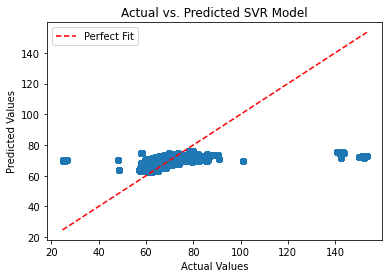

In [198]:
#From the r-squared scores obtained we can see that no matter the method used the data does not accurately 
# capture the causes behind the difference that exist. WE can show that the difference among states 
# is statistically significant but we can not explain why with the data used. 
# What this implies is that a much more robust dataset with more parameters would be necessary in order 
# to gain insight into why these differences exist.
#However we can make some visualizations of the models. First SVR, since it was the most recent model run
#Need matplotlib to plot the visualization 
import matplotlib.pyplot as plt 
y_pred=svr_model.predict(x_test)
#Create the plot
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label="Perfect Fit")
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted SVR Model')
plt.legend()
plt.show()

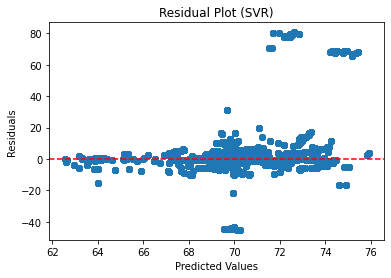

In [199]:
# Calculate residuals
residuals = y_test - y_pred

# Plot residuals
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot (SVR)')
plt.show()

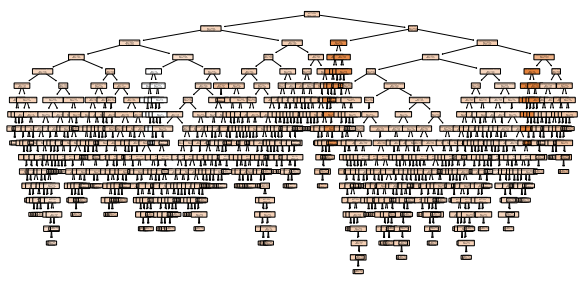

In [202]:
#Rerun the random forest regressor to reload the variables as the names arent changed between models
# Then create visualizations for random forest regressor 
#Load required libraries to make a tree visualization 
from sklearn.tree import export_graphviz
from sklearn.tree import plot_tree

# Visualize a single decision tree from the random forest
#Call the width and depth of the tree to be displayed
plt.figure(figsize=(10, 5))
#call the model using plot_tree using the columns of the x variable to label observations
plot_tree(rf_model.estimators_[0], filled=True, feature_names=x.columns, rounded=True)
#display the plot
plt.show()

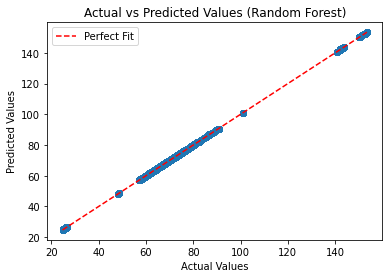

In [203]:
#Create a scatterplot graph like for the SVR but for the Random Forest Regressor instead 
# Predict the values using the model
y_pred = rf_model.predict(x_test)

# Create a scatter plot of actual vs predicted values
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Perfect Fit')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values (Random Forest)')
plt.legend()
plt.show()

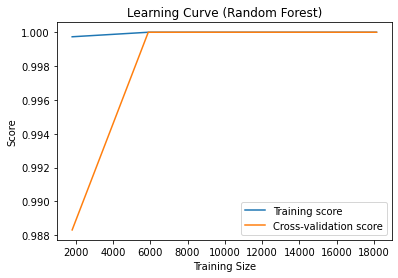

In [205]:
#As expected from the r2 value the fit of the model to the data is absolutety perfect, which indicates 
# an issue in implementing the model. As this model exhibits a perfect fit it indicates there was an issue 
# in splitting the data or the test size was not large enough to allow for generalization. 
# The learning curve can also be examined to see if the model is being overfit 
# Import the library needed to make the learning curve 
from sklearn.model_selection import learning_curve
#Set up the model for visualization specifying the number of cross validations to perform, in this case 5
train_sizes, train_scores, test_scores = learning_curve(rf_model, x_train, y_train, cv=5)

# Calculate average train and test scores across folds
train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

# Plot the learning curve
plt.plot(train_sizes, train_scores_mean, label='Training score')
plt.plot(train_sizes, test_scores_mean, label='Cross-validation score')
plt.xlabel('Training Size')
plt.ylabel('Score')
plt.title('Learning Curve (Random Forest)')
plt.legend()
plt.show()

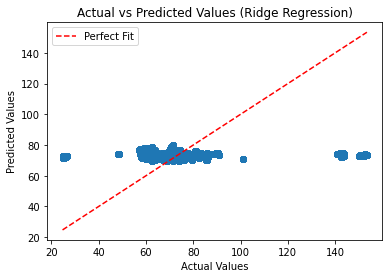

In [207]:
#And as seen with the scatterplot, we once again have an example of gross overfitment of the data. 
# Both the training score and the cross-validation score are equal to 1 which signifies overfitment. 
#Now that the visualizations for the random forest method have been made we can reload one of the other 
#models used and create visualizations for it as well. 
# Predict the values using the model
y_pred = ridge_model.predict(x_test)

# Create a scatter plot of actual vs predicted values
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Perfect Fit')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values (Ridge Regression)')
plt.legend()
plt.show()

In [208]:
#Once more as exhibited in the r2 score the scatterplot helps visualize the poor performance of the model
print(licensed_drivers.shape)

(57834, 5)
